In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("../data/processed/steam_games_targets.csv")

df.head()

,appid,name,release_date,developers,publishers,price,genres,categories,tags,supported_languages,achievements,windows,mac,linux,owners_midpoint,success_tier,total_reviews,reception_score
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,['minori'],['MangaGamer'],5.24,['Adventure'],"['Single-player', 'Steam Trading Cards', 'Stea...","{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",['English'],0,True,False,False,10000.0,0,255,0.988235
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,['Somer Games'],['8floor'],4.99,['Casual'],"['Single-player', 'Family Sharing']","{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...","['English', 'French', 'German', 'Russian']",0,True,True,False,10000.0,0,24,0.875000
2,1934300,Armored Brigade II,2025-04-08,['Veitikka Studios'],['Matrix Games'],35.99,"['Simulation', 'Strategy']","['Single-player', 'Steam Workshop', 'Steam Clo...","{'Simulation': 193, 'Strategy': 186, 'RTS': 16...",['English'],0,True,False,False,10000.0,0,130,0.900000
3,1157670,Hepta Beats,2021-05-07,['Matheus Bigatão'],['Matheus Bigatão'],0.99,"['Casual', 'Indie']","['Single-player', 'Steam Achievements', 'Full ...","{'Precision Platformer': 52, 'Rhythm': 45, 'Mu...","['English', 'French', 'Italian', 'German', 'Sp...",9,True,False,False,10000.0,0,32,0.875000
4,1540330,MUMBA IV: Egypt Jewels,2021-12-13,['Airem'],['Airem'],0.59,"['Action', 'Casual', 'Indie', 'Strategy']","['Single-player', 'Steam Achievements', 'Full ...","{'Casual': 64, 'Action': 51, 'Strategy': 42, '...","['English', 'French', 'Italian', 'German', 'Sp...",100,True,True,True,10000.0,0,25,0.760000


In [17]:
df.shape

(44584, 18)

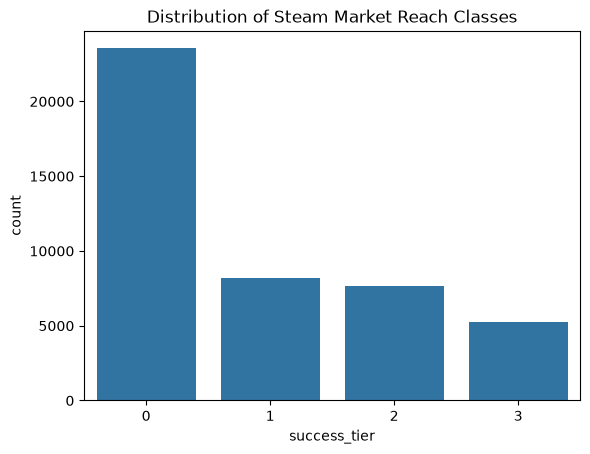

In [ ]:
# success tier distribution
sns.countplot(data=df, x="success_tier")

plt.title("Distribution of Steam Market Reach Classes")
plt.savefig("../reports/figures/success_distribution.png")

the distribution is imbalanced, so we cannot rely on accuracy, we'll probably use macro f1, confusion matrix


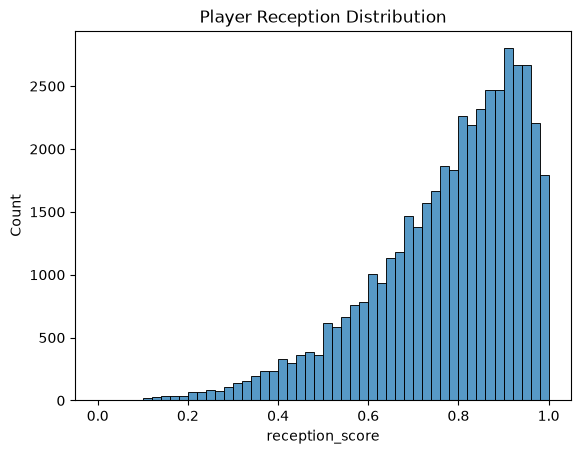

In [ ]:
# Reception Distribution
sns.histplot(df["reception_score"], bins=50)


plt.title("Player Reception Distribution")


plt.savefig("../reports/figures/reception_distribution.png")

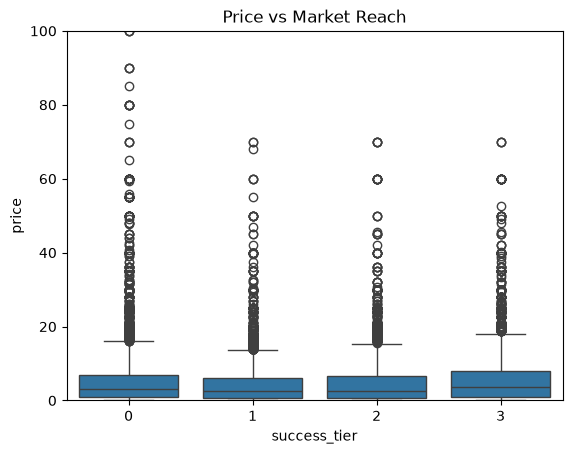

In [ ]:
# Price Analysis

sns.boxplot(data=df, x="success_tier", y="price")


plt.ylim(0, 100)


plt.title("Price vs Market Reach")

plt.savefig("../reports/figures/Price_MarketReach.png")

In [21]:
# Free vs Paid games

df["is_free"] = df["price"] == 0

df.groupby("is_free")["owners_midpoint"].median()

is_free
False    10000.0
True     35000.0
Name: owners_midpoint, dtype: float64

<Axes: xlabel='platform_count', ylabel='owners_midpoint'>

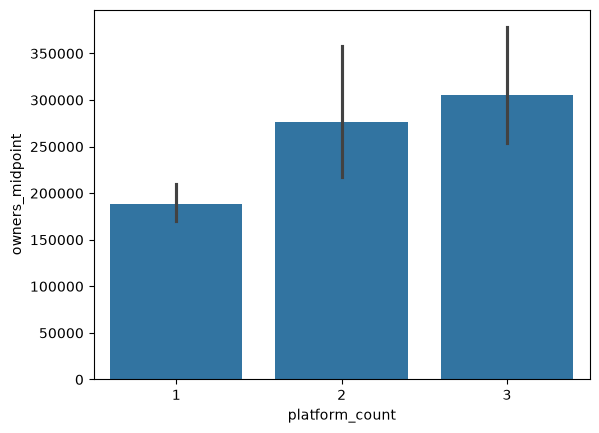

In [ ]:
# Platform Count analysis

df["platform_count"] = (
    df["windows"].astype(int) + df["mac"].astype(int) + df["linux"].astype(int)
)

sns.barplot(data=df, x="platform_count", y="owners_midpoint")

Text(0.5, 1.0, 'Platform Support vs Market Reach')

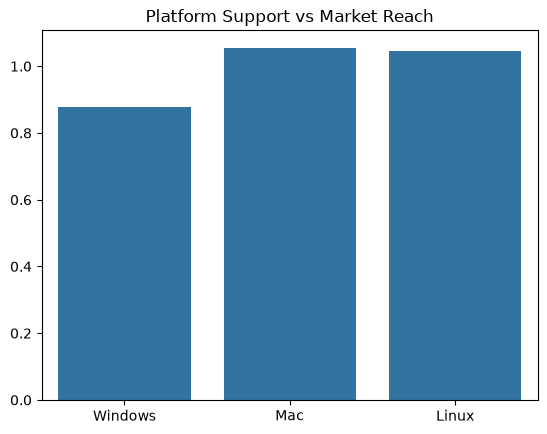

In [ ]:
# Platform VS Marker Reach

platform_success = {
    "Windows": df[df["windows"] == True]["success_tier"].mean(),
    "Mac": df[df["mac"] == True]["success_tier"].mean(),
    "Linux": df[df["linux"] == True]["success_tier"].mean(),
}

sns.barplot(x=list(platform_success.keys()), y=list(platform_success.values()))


plt.title("Platform Support vs Market Reach")

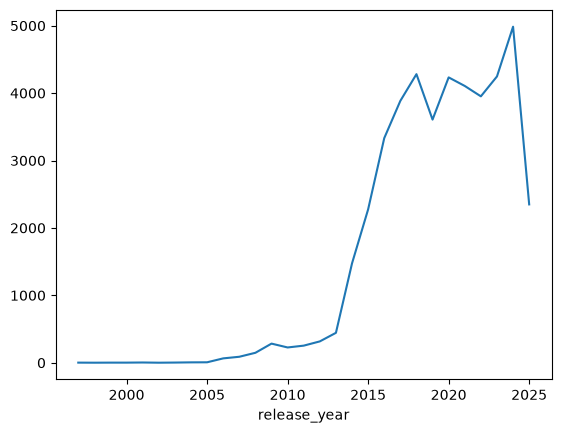

In [ ]:
# Release Year Trends
df["release_date"] = pd.to_datetime(df["release_date"])
df["release_year"] = df["release_date"].dt.year

df["release_year"].value_counts().sort_index().plot()

plt.savefig("../reports/figures/Release_year.png")

In [ ]:
# Summary Stats

summary_stats = {
    "total_games": len(df),
    "avg_reception": df["reception_score"].mean(),
    "median_price": df["price"].median(),
    "high_impact_rate": (df["success_tier"].eq(3).mean()),
}


summary_stats

{'total_games': 44584,
 'avg_reception': np.float64(0.7758593213876351),
 'median_price': np.float64(2.99),
 'high_impact_rate': np.float64(0.11723936838327652)}

In [ ]:
import ast


def parse_list_column(value):

    try:
        return ast.literal_eval(value)

    except:
        return []


df["genres_clean"] = df["genres"].apply(parse_list_column)

df["genres_clean"].head()

0                          [Adventure]
1                             [Casual]
2               [Simulation, Strategy]
3                      [Casual, Indie]
4    [Action, Casual, Indie, Strategy]
Name: genres_clean, dtype: object

In [51]:
# Genre analysis

df["genres"].head()

0                                ['Adventure']
1                                   ['Casual']
2                   ['Simulation', 'Strategy']
3                          ['Casual', 'Indie']
4    ['Action', 'Casual', 'Indie', 'Strategy']
Name: genres, dtype: str

In [ ]:
genre_counts = df["genres_clean"].explode().str.strip().value_counts().head(15)


genre_counts

genres_clean
Indie                    31662
Adventure                19077
Action                   18734
Casual                   16240
Simulation               10318
Strategy                  9386
RPG                       9090
Free To Play              3622
Early Access              3504
Sports                    1973
Racing                    1572
Massively Multiplayer     1213
Utilities                  400
Design & Illustration      265
Violent                    216
Name: count, dtype: int64

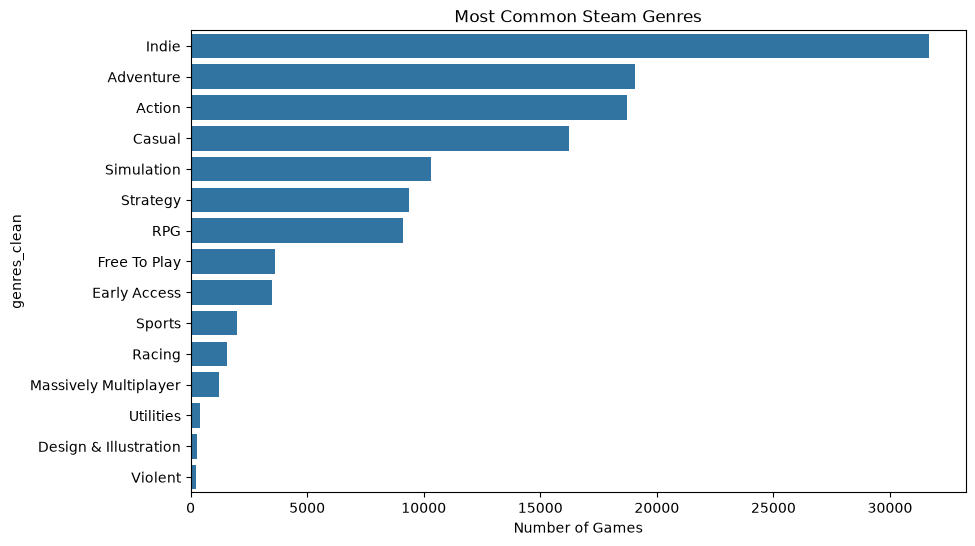

In [ ]:
plt.figure(figsize=(10, 6))


sns.barplot(x=genre_counts.values, y=genre_counts.index)


plt.title("Most Common Steam Genres")


plt.xlabel("Number of Games")


plt.savefig("../reports/figures/top_genres.png", bbox_inches="tight")

In [ ]:
# Genre Success rate

genre_df = df.explode("genres_clean")

In [ ]:
genre_df = genre_df.rename(columns={"genres_clean": "genre"})

In [ ]:
genre_stats = genre_df.groupby("genre").agg(
    avg_success=("success_tier", "mean"), game_count=("name", "count")
)

genre_stats = genre_stats[genre_stats["game_count"] >= 200]

top_success_genres = genre_stats.sort_values("avg_success", ascending=False).head(15)

In [ ]:
top_success_genres = genre_stats.sort_values("avg_success", ascending=False).head(15)

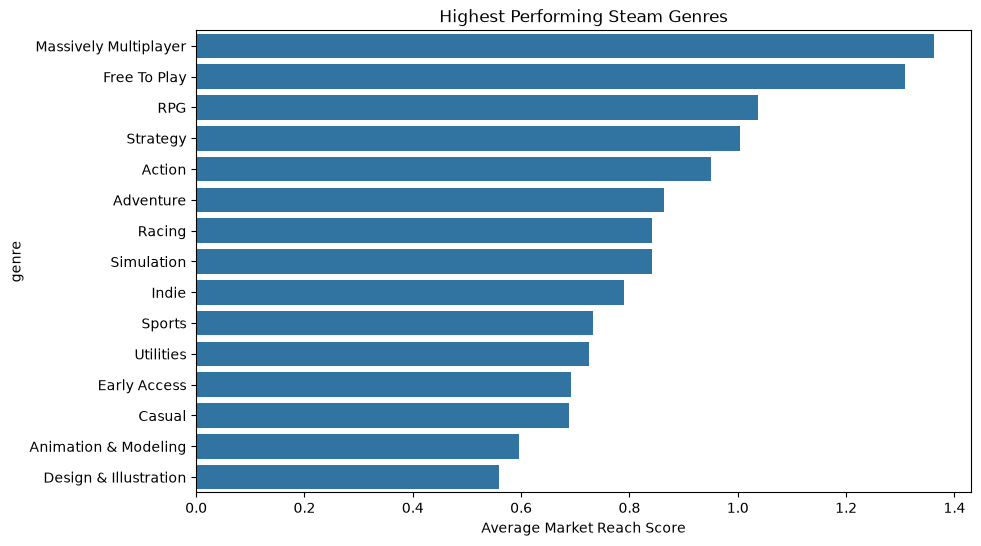

In [ ]:
plt.figure(figsize=(10, 6))


sns.barplot(data=top_success_genres, x="avg_success", y=top_success_genres.index)


plt.title("Highest Performing Steam Genres")


plt.xlabel("Average Market Reach Score")


plt.savefig("../reports/figures/genre_success.png", bbox_inches="tight")

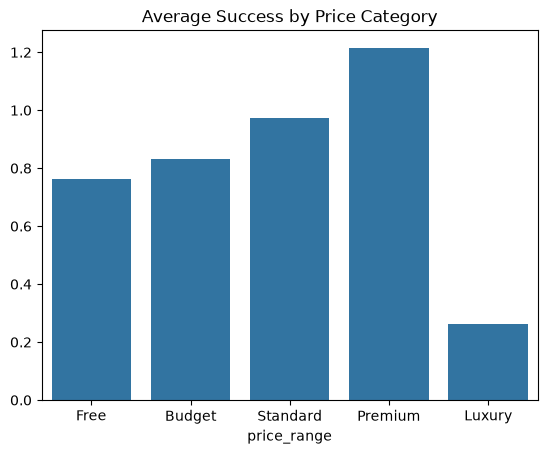

In [ ]:
# Price Sweet Spot Analysis

df["price_range"] = pd.cut(
    df["price"],
    bins=[0, 1, 10, 30, 60, 1000],
    labels=["Free", "Budget", "Standard", "Premium", "Luxury"],
)

price_success = df.groupby("price_range")["success_tier"].mean()

sns.barplot(x=price_success.index, y=price_success.values)


plt.title("Average Success by Price Category")

plt.savefig("../reports/figures/Price_SweetSpot.png", bbox_inches="tight")

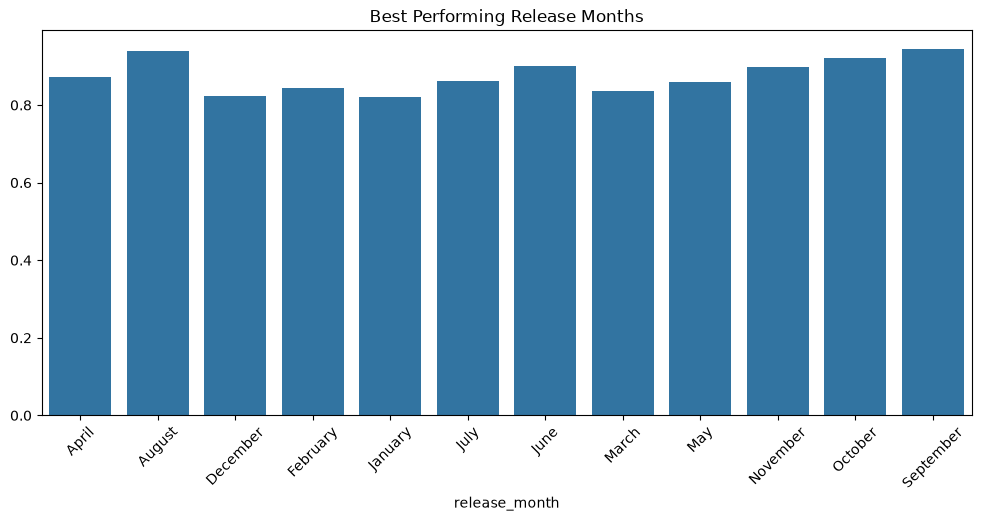

In [ ]:
# Release Month Analysis

df["release_month"] = pd.to_datetime(df["release_date"]).dt.month_name()

monthly_success = df.groupby("release_month")["success_tier"].mean()

plt.figure(figsize=(12, 5))


sns.barplot(x=monthly_success.index, y=monthly_success.values)


plt.xticks(rotation=45)


plt.title("Best Performing Release Months")

plt.savefig("../reports/figures/Release_month.png", bbox_inches="tight")

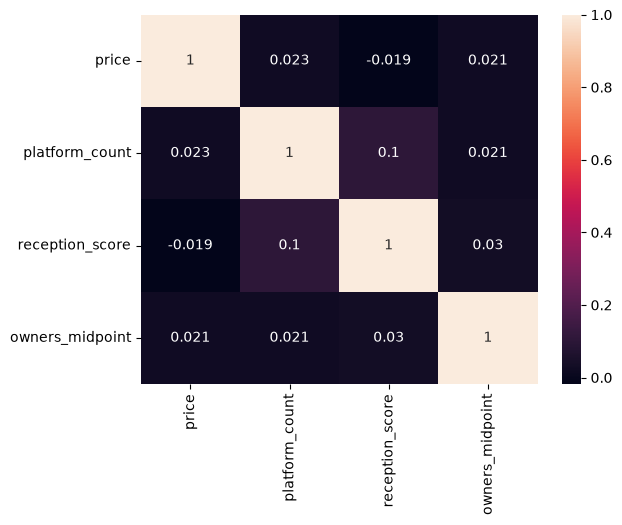

In [ ]:
numeric_cols = ["price", "platform_count", "reception_score", "owners_midpoint"]


sns.heatmap(df[numeric_cols].corr(), annot=True)

plt.savefig("../reports/figures/Numeric_Corr.png", bbox_inches="tight")